# Preparing the Dataset

In [44]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub as kh

from sklearn.model_selection import train_test_split
#from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
#loading the dataset

path = kh.dataset_download("thirumani/shark-tank-us-dataset", output_dir="C:\\Users\\Prisha\\Documents\\DS 3021\\Final Project\\DS-3021-Final-Project\\Shark-Tank-US-Data")


In [3]:
df = pd.read_csv(path + "/Shark Tank US Dataset.csv")

In [3]:
#doing this locally on my computer
df = pd.read_csv("sharktankdata.csv")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1485 entries, 0 to 1484
Data columns (total 53 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Season Number                       1485 non-null   int64  
 1   Startup Name                        1485 non-null   str    
 2   Episode Number                      1485 non-null   int64  
 3   Pitch Number                        1485 non-null   int64  
 4   Season Start                        1485 non-null   str    
 5   Season End                          1441 non-null   str    
 6   Original Air Date                   1485 non-null   str    
 7   Industry                            1485 non-null   str    
 8   Business Description                1485 non-null   str    
 9   Company Website                     961 non-null    str    
 10  Pitchers Gender                     1476 non-null   str    
 11  Pitchers Average Age                547 non-null    st

In [25]:
df.describe()

,Season Number,Episode Number,Pitch Number,Multiple Entrepreneurs,US Viewership,Original Ask Amount,Original Offered Equity,Valuation Requested,Got Deal,Total Deal Amount,...,Kevin O Leary Investment Equity,Guest Investment Amount,Guest Investment Equity,Barbara Corcoran Present,Mark Cuban Present,Lori Greiner Present,Robert Herjavec Present,Daymond John Present,Kevin O Leary Present,Guest Present
count,1485.000000,1485.000000,1485.000000,1056.000000,1473.000000,1.481000e+03,1481.000000,1.481000e+03,1481.000000,9.140000e+02,...,138.000000,1.530000e+02,153.000000,1006.000000,1064.000000,1112.000000,988.000000,998.000000,1109.000000,147.000000
mean,9.039057,12.160269,743.000000,0.458333,4.829335,2.821296e+05,13.098359,3.669953e+06,0.617151,2.891271e+05,...,14.968237,2.083834e+05,14.635948,0.611332,0.917293,0.798561,0.886640,0.695391,0.963931,1.163265
std,4.421198,7.335797,428.826888,0.498497,1.603174,3.446770e+05,8.397064,5.789331e+06,0.486246,3.379407e+05,...,10.869582,2.001617e+05,12.141537,0.487690,0.275568,0.401256,0.317193,0.460472,0.186545,0.370871
min,1.000000,1.000000,1.000000,0.000000,1.370000,1.000000e+04,1.000000,4.000000e+04,0.000000,1.000000e+04,...,0.000000,2.000000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,5.000000,6.000000,372.000000,0.000000,3.570000,1.000000e+05,8.000000,7.500000e+05,0.000000,1.000000e+05,...,6.562500,7.500000e+04,8.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
50%,9.000000,11.000000,743.000000,0.000000,4.550000,2.000000e+05,10.000000,1.800000e+06,1.000000,2.000000e+05,...,10.833333,1.500000e+05,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,13.000000,18.000000,1114.000000,1.000000,6.130000,3.430000e+05,20.000000,4.000000e+06,1.000000,3.150000e+05,...,20.000000,2.500000e+05,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,17.000000,29.000000,1485.000000,1.000000,8.640000,5.000000e+06,100.000000,1.000000e+08,1.000000,5.000000e+06,...,50.000000,1.250000e+06,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000


In [26]:
print(df.isna().sum())

Season Number                            0
Startup Name                             0
Episode Number                           0
Pitch Number                             0
Season Start                             0
Season End                              44
Original Air Date                        0
Industry                                 0
Business Description                     0
Company Website                        524
Pitchers Gender                          9
Pitchers Average Age                   938
Pitchers City                          667
Pitchers State                         539
Entrepreneur Names                     499
Multiple Entrepreneurs                 429
US Viewership                           12
Original Ask Amount                      4
Original Offered Equity                  4
Valuation Requested                      4
Got Deal                                 4
Total Deal Amount                      571
Total Deal Equity                      571
Deal Valuat

In [27]:
df_clean = df.drop(df.columns[31:46], axis=1) # data leakage

drop_cols = ['Season Number', 'Startup Name', 'Episode Number', # Unneeded info
             'Pitch Number', 'Season Start', 'Season End', 'Original Air Date', # Unneeded info
             'Business Description', 'Company Website', # Unneeded info
             'Pitchers Average Age', 'Pitchers City', 'Pitchers State', # Missing many values
             'Entrepreneur Names', 'Guest Present', # Unneeded info
             'Valuation Requested', # Redundant 
             'Total Deal Amount', 'Total Deal Equity', 'Deal Valuation', 'Number of Sharks in Deal', # data leakage
             'Equity Per Shark', 'Investment Amount Per Shark', 'Royalty Deal', 'Advisory Shares Equity', # data leakage
             'Loan', 'Deal Has Conditions'] # data leakage

df_clean.drop(columns=drop_cols, inplace=True)

In [29]:
# missing values in when shark's are not present replaced with 0 to represent that they were not present
# they line up with seasons they were not present in mostly

df_clean.iloc[:, 7:14] = df_clean.iloc[:, 7:14].fillna(0)
print(df_clean.isna().sum())

Industry                      0
Pitchers Gender               9
Multiple Entrepreneurs      429
US Viewership                12
Original Ask Amount           4
Original Offered Equity       4
Got Deal                      4
Barbara Corcoran Present      0
Mark Cuban Present            0
Lori Greiner Present          0
Robert Herjavec Present       0
Daymond John Present          0
Kevin O Leary Present         0
dtype: int64


In [ ]:
df_clean['Multiple Entrepreneurs'] = df_clean['Multiple Entrepreneurs'].fillna('Unknown')
df_clean.dropna(inplace=True)
print(df_clean.isna().sum())

Industry                    0
Pitchers Gender             0
Multiple Entrepreneurs      0
US Viewership               0
Original Ask Amount         0
Original Offered Equity     0
Got Deal                    0
Barbara Corcoran Present    0
Mark Cuban Present          0
Lori Greiner Present        0
Robert Herjavec Present     0
Daymond John Present        0
Kevin O Leary Present       0
dtype: int64


In [31]:
# Checking the numercal columns for outliers and distribution

df_clean.describe()

,US Viewership,Original Ask Amount,Original Offered Equity,Got Deal,Barbara Corcoran Present,Mark Cuban Present,Lori Greiner Present,Robert Herjavec Present,Daymond John Present,Kevin O Leary Present
count,1466.000000,1.466000e+03,1466.000000,1466.000000,1466.000000,1466.000000,1466.000000,1466.000000,1466.000000,1466.000000
mean,4.834598,2.825130e+05,13.126651,0.614598,0.416780,0.665757,0.597544,0.594816,0.470668,0.721010
std,1.604544,3.460396e+05,8.411763,0.486856,0.493194,0.471886,0.490560,0.491095,0.499309,0.448656
min,1.370000,1.000000e+04,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.570000,1.000000e+05,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.550000,2.000000e+05,10.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000
75%,6.130000,3.500000e+05,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,8.640000,5.000000e+06,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


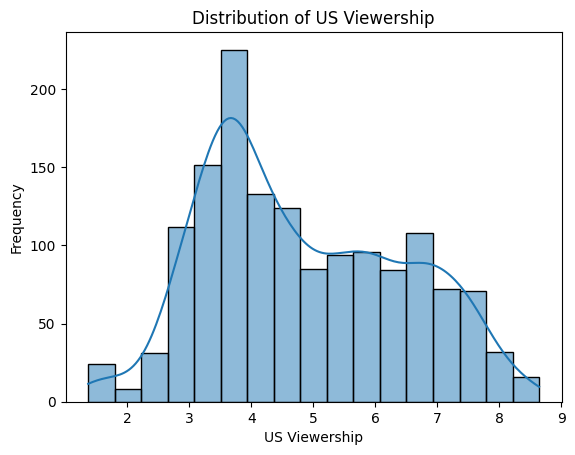

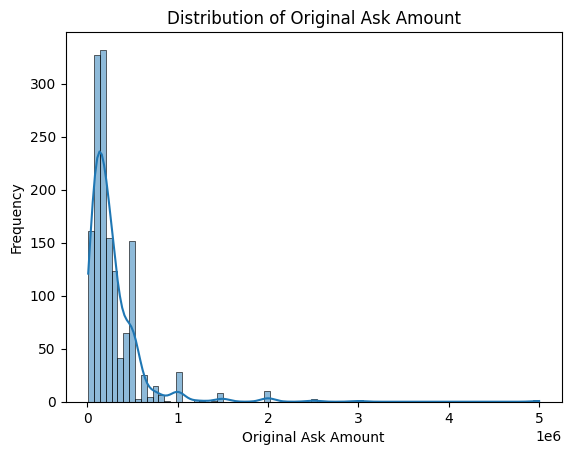

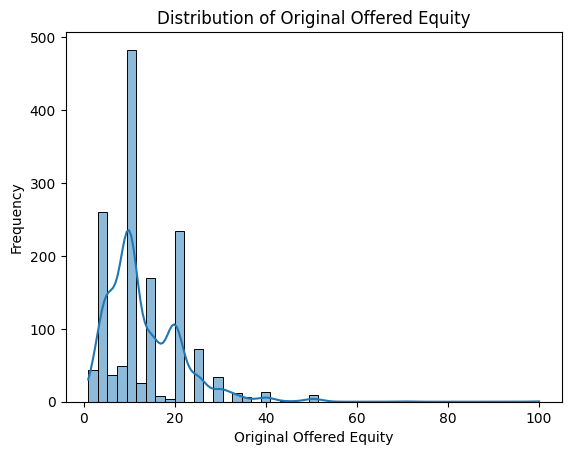

In [32]:
num_cols = ['US Viewership', 'Original Ask Amount', 'Original Offered Equity']

for col in num_cols:
    sns.histplot(df_clean[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


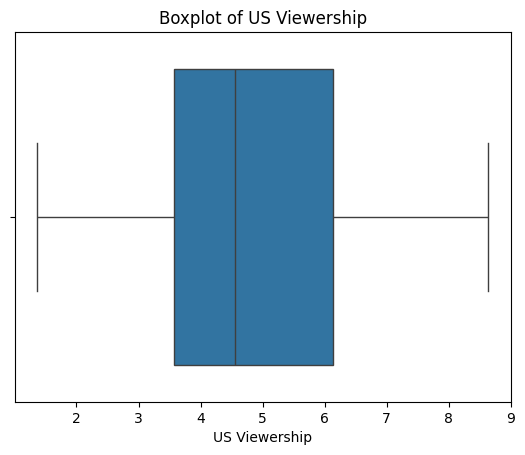

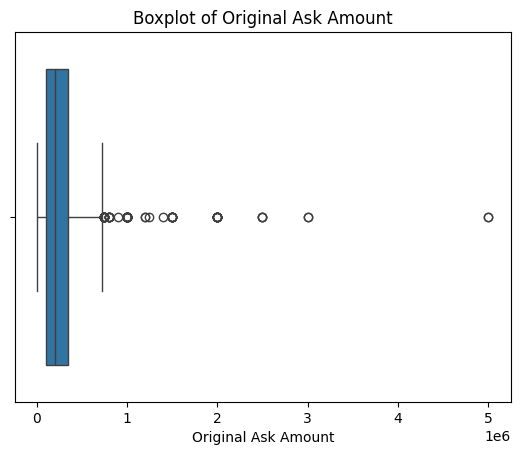

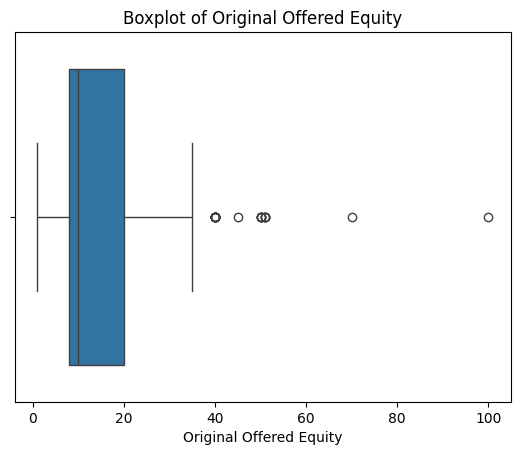

In [33]:
for col in num_cols:
    sns.boxplot(x=df_clean[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()


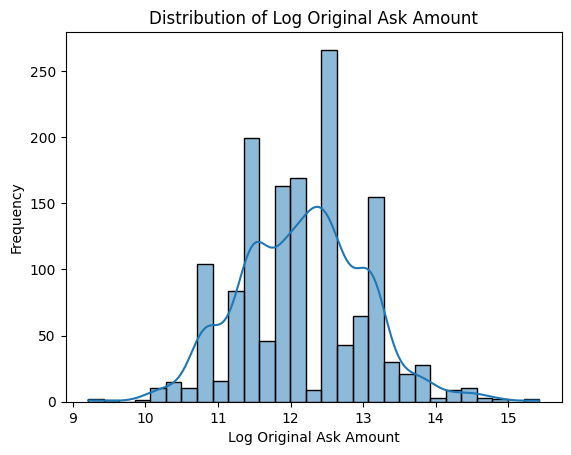

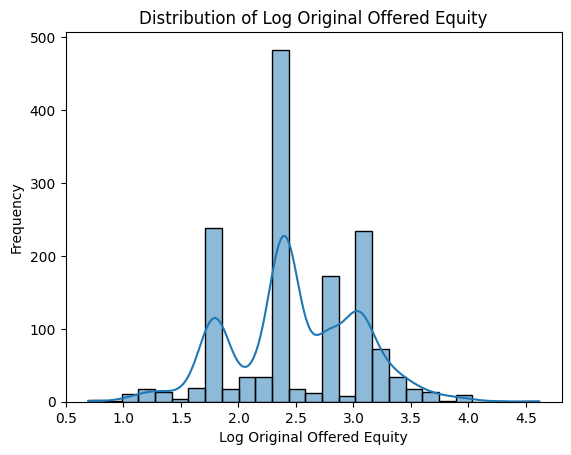

In [34]:
# Original Ask Amount and Original Offered Equity are skewed to the right, so a log transformation will be applied
df_clean['Log Original Ask Amount'] = np.log1p(df_clean['Original Ask Amount'])
df_clean['Log Original Offered Equity'] = np.log1p(df_clean['Original Offered Equity'])

# checking the distribution after log transformation
for col in ['Log Original Ask Amount', 'Log Original Offered Equity']:
    sns.histplot(df_clean[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [45]:
#normalize US Viewership using min-max scaling sklearn
scaler = MinMaxScaler()
df_clean['US Viewership Scaled'] = scaler.fit_transform(df_clean[['US Viewership']])
df_clean.head()

,Multiple Entrepreneurs,US Viewership,Original Ask Amount,Original Offered Equity,Got Deal,Barbara Corcoran Present,Mark Cuban Present,Lori Greiner Present,Robert Herjavec Present,Daymond John Present,...,Log Original Offered Equity,Industry_Fashion/Beauty,Industry_Fitness/Health,Industry_Food/Beverage,Industry_Lifestyle/Home,Industry_Other,Industry_Tech/Electronics,Pitchers Gender_Male,Pitchers Gender_Mixed Team,US Viewership Scaled
0,0.0,4.15,50000.0,15.0,1.0,1.0,0.0,0.0,1.0,1.0,...,2.772589,False,True,False,False,False,False,False,False,0.382393
1,0.0,4.15,460000.0,10.0,1.0,1.0,0.0,0.0,1.0,1.0,...,2.397895,False,False,True,False,False,False,True,False,0.382393
2,0.0,4.15,1200000.0,10.0,0.0,1.0,0.0,0.0,1.0,1.0,...,2.397895,False,False,False,False,True,False,True,False,0.382393
3,0.0,4.15,250000.0,25.0,0.0,1.0,0.0,0.0,1.0,1.0,...,3.258097,False,False,False,True,False,False,True,False,0.382393
4,0.0,4.15,1000000.0,15.0,0.0,1.0,0.0,0.0,1.0,1.0,...,2.772589,False,False,False,False,False,True,True,False,0.382393


### Categorical Columns

In [35]:
cat_cols = ["Industry", "Pitchers Gender"]

In [36]:
#These categorical variables have multiple categories, so we will one hot encode
print(df_clean["Industry"].value_counts())

Industry
Food and Beverage          316
Lifestyle/Home             257
Fashion/Beauty             238
Fitness/Sports/Outdoors    151
Children/Education         133
Health/Wellness             71
Technology/Software         69
Pet Products                62
Business Services           42
Media/Entertainment         32
Uncertain/Other             23
Electronics                 18
Automotive                  17
Green/CleanTech             14
Liquor/Alcohol              12
Travel                      11
Name: count, dtype: int64


In [41]:
#Creating groupings

#This organization maintains the six most frequent categories while also creating reasonable groupings for similar categories.
df_clean['Industry'] = df_clean['Industry'].replace(['Technology/Software', 'Electronics'], 'Tech/Electronics') #Tech and Electronics industries are similar
df_clean['Industry'] = df_clean['Industry'].replace(['Food and Beverage', "Liquor/Alcohol"], 'Food/Beverage') #Alcohol can be appedned to food/beverage industry
df_clean['Industry'] = df_clean['Industry'].replace(['Fitness/Sports/Outdoors', 'Health/Wellness'], 'Fitness/Health') #Fitness and Health industries are similar

df_clean['Industry'] = df_clean['Industry'].replace(['Pet Products', 'Business Services', 'Media/Entertainment', 'Uncertain/Other',
                                                         'Automotive','Green/CleanTech','Travel'], 'Other') #these lower frequency categories are grouped together


df_clean['Industry'].value_counts()

Industry
Food/Beverage         328
Lifestyle/Home        257
Fashion/Beauty        238
Fitness/Health        222
Other                 201
Children/Education    133
Tech/Electronics       87
Name: count, dtype: int64

In [42]:
#One hot encoding the cat variables
df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

In [46]:
df_clean.head()

,Multiple Entrepreneurs,US Viewership,Original Ask Amount,Original Offered Equity,Got Deal,Barbara Corcoran Present,Mark Cuban Present,Lori Greiner Present,Robert Herjavec Present,Daymond John Present,...,Log Original Offered Equity,Industry_Fashion/Beauty,Industry_Fitness/Health,Industry_Food/Beverage,Industry_Lifestyle/Home,Industry_Other,Industry_Tech/Electronics,Pitchers Gender_Male,Pitchers Gender_Mixed Team,US Viewership Scaled
0,0.0,4.15,50000.0,15.0,1.0,1.0,0.0,0.0,1.0,1.0,...,2.772589,False,True,False,False,False,False,False,False,0.382393
1,0.0,4.15,460000.0,10.0,1.0,1.0,0.0,0.0,1.0,1.0,...,2.397895,False,False,True,False,False,False,True,False,0.382393
2,0.0,4.15,1200000.0,10.0,0.0,1.0,0.0,0.0,1.0,1.0,...,2.397895,False,False,False,False,True,False,True,False,0.382393
3,0.0,4.15,250000.0,25.0,0.0,1.0,0.0,0.0,1.0,1.0,...,3.258097,False,False,False,True,False,False,True,False,0.382393
4,0.0,4.15,1000000.0,15.0,0.0,1.0,0.0,0.0,1.0,1.0,...,2.772589,False,False,False,False,False,True,True,False,0.382393


### Creating Pipeline

In [ ]:
# I think we need to make preprocsser ??
# we could do something like: we have columns named "nums to log" "nums to scale" and "categorical", then preprocss them accordingly??


preprocessor = ColumnTransformer(
    transformers=[
        ('num to log', MinMaxScaler(), num_to_log),
        ('num to scale', MinMaxScaler(), num_to_scale),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ])